In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter

In [2]:
df=pd.read_excel("sba_loan_dataset.xlsx")

In [3]:
df.head(5)

,location_id,bank_name,bank_city,bank_state,gross_approval,sba_guaranteed_approval,approval_date,approval_fy,first_disbursement_date,processing_method,...,naics_description,project_state,sba_district_office,business_type,business_age,loan_status,paid_in_full_date,charge_off_date,gross_charge_off_Amount,collateral_ind
0,29805,"TD Bank, National Association",WILMINGTON,DE,25000,12500.0,10/1/2019,2020,10/31/2019,SBA Express Program,...,Commercial and Institutional Building Construc...,PA,PHILADELPHIA DISTRICT OFFICE,PARTNERSHIP,Unanswered,PIF,11/30/2024,NaN,0.0,N
1,84894,"Santander Bank, National Association",WILMINGTON,DE,95800,47900.0,10/1/2019,2020,10/31/2019,SBA Express Program,...,Full-Service Restaurants,NY,NEW YORK DISTRICT OFFICE,CORPORATION,Existing or more than 2 years old,PIF,11/30/2023,NaN,0.0,N
2,53803,"U.S. Bank, National Association",Cincinnati,OH,40000,20000.0,10/1/2019,2020,2/29/2020,SBA Express Program,...,Landscaping Services,CA,SACRAMENTO DISTRICT OFFICE,INDIVIDUAL,Unanswered,PIF,11/30/2024,NaN,0.0,Y
3,123499,BayFirst National Bank,Saint Petersburg,FL,125000,106250.0,10/1/2019,2020,10/31/2019,Preferred Lenders Program,...,All Other Support Services,TX,SAN ANTONIO DISTRICT OFFICE,CORPORATION,Existing or more than 2 years old,EXEMPT,NaN,NaN,0.0,N
4,70400,Golden Bank National Association,HOUSTON,TX,250000,187500.0,10/1/2019,2020,12/31/2019,Preferred Lenders Program,...,Full-Service Restaurants,TX,HOUSTON DISTRICT OFFICE,CORPORATION,Unanswered,PIF,1/31/2024,NaN,0.0,Y


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 347514 entries, 0 to 347513
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   location_id                     347514 non-null  int64  
 1   bank_name                       347514 non-null  str    
 2   bank_city                       347514 non-null  str    
 3   bank_state                      347514 non-null  str    
 4   gross_approval                  347514 non-null  int64  
 5   sba_guaranteed_approval         347514 non-null  float64
 6   approval_date                   347514 non-null  str    
 7   approval_fy                     347514 non-null  int64  
 8   first_disbursement_date         293909 non-null  str    
 9   processing_method               347514 non-null  str    
 10  initial_interest_rate           347508 non-null  float64
 11  fixed_or_variable_interest_ind  347508 non-null  str    
 12  term_in_months             

In [5]:
df.describe()

,location_id,gross_approval,sba_guaranteed_approval,approval_fy,initial_interest_rate,term_in_months,gross_charge_off_Amount
count,347514.000000,3.475140e+05,3.475140e+05,347514.000000,347508.000000,347514.000000,3.475140e+05
mean,121173.852302,5.200018e+05,3.929935e+05,2022.850694,8.728715,138.592897,2.586392e+03
std,146239.635678,8.603794e+05,6.670194e+05,1.705306,2.791770,70.529183,4.462488e+04
min,27.000000,1.000000e+03,5.000000e+02,2020.000000,0.000000,0.000000,0.000000e+00
25%,39052.000000,5.030000e+04,3.750000e+04,2021.000000,6.000000,120.000000,0.000000e+00
50%,57328.000000,1.900000e+05,1.275000e+05,2023.000000,9.200000,120.000000,0.000000e+00
75%,119918.000000,5.000000e+05,3.878438e+05,2024.000000,10.750000,120.000000,0.000000e+00
max,615003.000000,5.000000e+06,4.500000e+06,2025.000000,16.500000,420.000000,4.633000e+06


In [6]:
df.duplicated().sum()

np.int64(584)

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['initial_interest_rate']=df.groupby('processing_method')['initial_interest_rate'].transform(lambda x:x.fillna(x.median()))
df['fixed_or_variable_interest_ind']=df.groupby('processing_method')['fixed_or_variable_interest_ind'].transform(lambda x:x.fillna(x.mode()[0]))
df['business_type']=df['business_type'].fillna('Unknown')
df['business_age']=df['business_age'].fillna('Unknown')

In [10]:
df.isnull().sum()

location_id                            0
bank_name                              0
bank_city                              0
bank_state                             0
gross_approval                         0
sba_guaranteed_approval                0
approval_date                          0
approval_fy                            0
first_disbursement_date            53259
processing_method                      0
initial_interest_rate                  0
fixed_or_variable_interest_ind         0
term_in_months                         0
naics_description                      0
project_state                          0
sba_district_office                    0
business_type                          0
business_age                           0
loan_status                            0
paid_in_full_date                 278884
charge_off_date                   340042
gross_charge_off_Amount                0
collateral_ind                         0
dtype: int64

In [11]:
df['first_disbursement_date']=df['first_disbursement_date'].fillna(pd.NaT)
df['paid_in_full_date']=df['paid_in_full_date'].fillna(pd.NaT)
df['charge_off_date']=df['charge_off_date'].fillna(pd.NaT)

In [12]:
df['business_type']=df['business_type'].str.strip().str.title()
df['sba_district_office']=df['sba_district_office'].str.strip().str.title()
df['bank_city']=df['bank_city'].str.strip().str.title()

In [13]:
total_loan=df.shape[0]
print(total_loan)

346930


In [14]:
# What is the overall SBA loan charge_off (default) rate among loans that were either paid or charged off?

resolved_loans=df[df['loan_status'].isin(['CHGOFF','PIF'])]

#Total default loans
default_total = (resolved_loans['loan_status']== 'CHGOFF').sum()

#Total paid-in_full loans

pif_total= (resolved_loans['loan_status']=='PIF').sum()


#Total resolved loan

total_resolved=len(resolved_loans)

#default ratev

default_rate= (default_total/total_resolved) *100 

print("Default loans:", default_total)
print("PIF loans:", pif_total)
print("Total resolved loans:", total_resolved)
print("Default rate:", round(default_rate, 2), "%")

Default loans: 6893
PIF loans: 68045
Total resolved loans: 74938
Default rate: 9.2 %


In [15]:
# What is the total dollar amount of SBA loans approved each year from 2020 to 2025, excluding cancelled loans?


df['approval_year']=pd.to_datetime(df['approval_date']).dt.year

yearly_approvals=(df[(df['loan_status']!='CANCLD')& (df['approval_year'].between(2020,2025))]
              .groupby('approval_year')
              .agg(total_loans=('loan_status','size'), total_approved_amount=('gross_approval','sum') )
           .reset_index())

yearly_approvals

,approval_year,total_loans,total_approved_amount
0,2020,33675,19102002100
1,2021,45552,31674197800
2,2022,46116,25437862800
3,2023,52978,24023561400
4,2024,66165,29373113400
5,2025,47472,24634948700


In [16]:
#How many loans were charged off (defaulted) each year from 2020 to 2025?

df['approval_year']=pd.to_datetime(df['approval_date']).dt.year


resolved=df[df['loan_status'].isin(['PIF','CHGOFF'])].copy()

resolved = resolved[resolved['approval_year'].between(2020, 2025)]

yearly_default= (resolved.groupby('approval_year').agg(total_resolved_loans=('loan_status','size'),
                            chgoff_loans=('loan_status', lambda x:(x=='CHGOFF').sum())).reset_index())
 
yearly_default['chgoff_rate']=( yearly_default['chgoff_loans']/yearly_default['total_resolved_loans']*100).round(2)


yearly_default['chgoff_rate'] = (yearly_default['chgoff_rate'].astype(str) + '%')


yearly_default = (resolved.groupby('approval_year').agg(total_resolved_loans=('loan_status', 'size'),
                                                        chgoff_loans=('loan_status',lambda x: (x == 'CHGOFF').sum())).reset_index())

yearly_default

,approval_year,total_resolved_loans,chgoff_loans
0,2020,20512,1204
1,2021,19618,1336
2,2022,12779,1844
3,2023,8924,1510
4,2024,5274,432
5,2025,1298,40


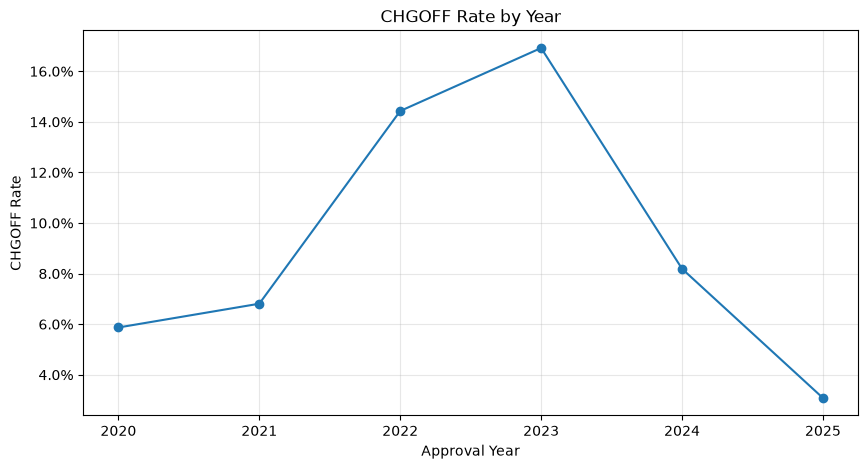

In [17]:
plt.figure(figsize=(10,5))
plt.plot(
    yearly_default['approval_year'],
    yearly_default['chgoff_loans']  / 
    yearly_default['total_resolved_loans']*100,
    marker='o'
)

plt.title('CHGOFF Rate by Year')
plt.xlabel('Approval Year')
plt.ylabel('CHGOFF Rate')
plt.xticks(yearly_default['approval_year'])
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
# Which 5 industries have the highest charge off rates among industries with at least 50 resolved loans?


df['chargeoff']=(df['loan_status']=='CHGOFF').astype(int)

industry_risk=(
    df[
        df['loan_status'].isin(['PIF','CHGOFF']) & df['naics_description'].notna()].groupby('naics_description')
                .agg(total_loans=('loan_status','size'), chargeoff_loans=('chargeoff','sum')))

industry_risk['chargeoff_rate']=(industry_risk['chargeoff_loans'] / industry_risk['total_loans']*100).round(2)

industry_risk=(industry_risk[industry_risk['total_loans']>=50].sort_values('chargeoff_rate',ascending=False).head(5).reset_index())

industry_risk['chargeoff_rate']=(industry_risk['chargeoff_rate'].astype(str)+'%')

industry_risk

,naics_description,total_loans,chargeoff_loans,chargeoff_rate
0,"Cosmetics, Beauty Supplies, and Perfume Retailers",65,26,40.0%
1,"General Freight Trucking, Long-Distance, Less ...",50,18,36.0%
2,Marketing Consulting Services,197,67,34.01%
3,"Independent Artists, Writers, and Performers",51,17,33.33%
4,All Other Miscellaneous Retailers,103,34,33.01%


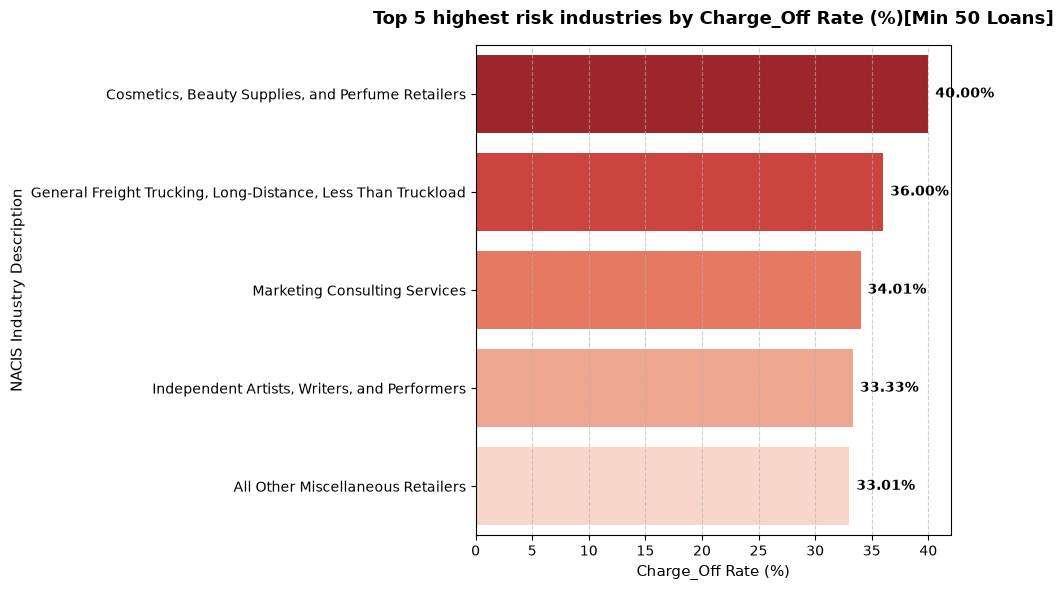

In [19]:
plot_data= industry_risk.copy()
plot_data["rate_numeric"]=plot_data["chargeoff_rate"].str.rstrip("%").astype(float)

plt.figure(figsize=(10,6))

ax= sns.barplot(
    data=plot_data,
    x="rate_numeric",
    y="naics_description",
    hue="naics_description",
    legend=False,
    palette="Reds_r"
)

plt.title("Top 5 highest risk industries by Charge_Off Rate (%)[Min 50 Loans]", fontsize=13, pad=15, weight="bold")
plt.xlabel("Charge_Off Rate (%)", fontsize=11)
plt.ylabel("NACIS Industry Description", fontsize=11)
plt.grid(axis="x",linestyle="--", alpha=0.6)

for p in ax.patches:         
    width=p.get_width()
    ax.annotate(
        f"{width:.2f}%",
        (width,p.get_y() + p.get_height()/ 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
        weight="bold"
 )
plt.tight_layout()
plt.show() 

In [20]:
# Which 5 industries have the highest charged-off loan amount among industries with at least 50 resolved loans?


df["naics_description"] = df["naics_description"].str.strip()


df["chargeoff"] = (df["loan_status"] == "CHGOFF").astype(int)


industry_exposure = (
    df[df["loan_status"].isin(["PIF", "CHGOFF"])].groupby("naics_description").agg(total_loans=("loan_status", "size"),
        chgoff_loans=("chargeoff", "sum"),
        charged_off_amount=("gross_charge_off_Amount", "sum"),))

industry_exposure["chgoff_rate"] = (
    industry_exposure["chgoff_loans"] / industry_exposure["total_loans"] * 100
).round(2)

industry_exposure = industry_exposure[industry_exposure["total_loans"] > 50]

industry_exposure = (
    industry_exposure.sort_values("charged_off_amount", ascending=False)
    .head(5)
    .reset_index()
)


display = industry_exposure.copy()
display["chgoff_rate"] = display["chgoff_rate"].map("{:.2f}%".format)
display["charged_off_amount"] = display["charged_off_amount"].map("${:,.0f}".format)

display

,naics_description,total_loans,chgoff_loans,charged_off_amount,chgoff_rate
0,Limited-Service Restaurants,2398,222,"$44,078,295",9.26%
1,Full-Service Restaurants,2946,296,"$40,271,267",10.05%
2,"General Freight Trucking, Long-Distance, Truck...",1922,341,"$28,587,960",17.74%
3,"General Freight Trucking, Local",1694,253,"$24,867,586",14.94%
4,Fitness and Recreational Sports Centers,1302,127,"$24,008,600",9.75%


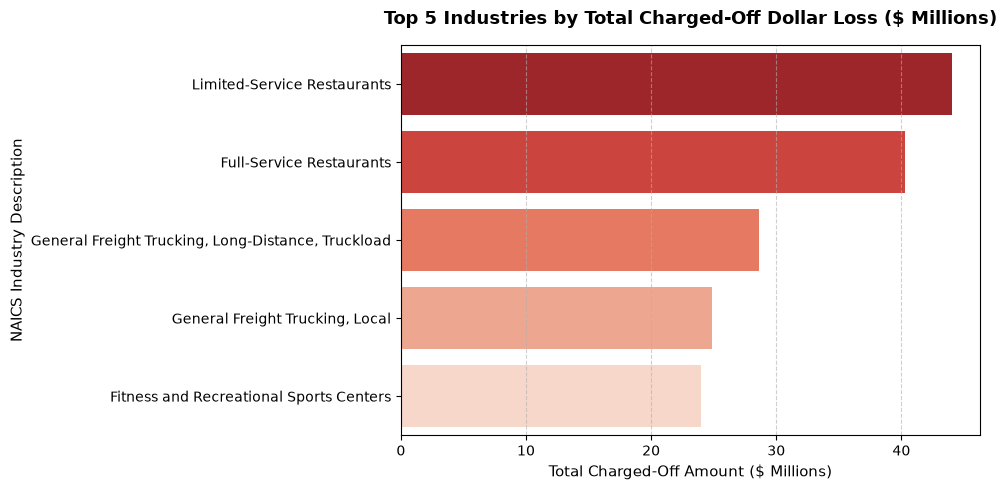

In [21]:
plot_data = industry_exposure.copy()

plot_data["amount_millions"] = (
    plot_data["charged_off_amount"] / 1_000_000
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=plot_data,
    x="amount_millions",
    y="naics_description",
    hue="naics_description",
    legend=False,
    palette="Reds_r"
)

plt.title(
    "Top 5 Industries by Total Charged-Off Dollar Loss ($ Millions)",
    fontsize=13,
    pad=15,
    weight="bold"
)

plt.xlabel("Total Charged-Off Amount ($ Millions)", fontsize=11)
plt.ylabel("NAICS Industry Description", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [22]:
#Which five processing methods have the highest charge off rates and total charged off amounts?

processing_risk=( df[df['loan_status'].isin(['PIF','CHGOFF'])].groupby('processing_method')
    .agg(total_loans=('loan_status','size'),chgoff_loans=('chargeoff','sum'), charged_off_amount=('gross_charge_off_Amount', 'sum')))

processing_risk['chgoff_rate']=(processing_risk['chgoff_loans']/processing_risk['total_loans']*100).round(2)

processing_risk = processing_risk[processing_risk["total_loans"] >= 50]

processing_risk=(processing_risk.sort_values('chgoff_rate', ascending=False).head(5).reset_index())

display=processing_risk.copy()
display['chgoff_rate']=display['chgoff_rate'].map("{:.2f}%".format)
display["charged_off_amount"] = display["charged_off_amount"].map("${:,.0f}".format)
display


,processing_method,total_loans,chgoff_loans,charged_off_amount,chgoff_rate
0,Community Advantage Initiative,808,229,"$28,994,188",28.34%
1,SBA Express Program,35766,4370,"$206,176,915",12.22%
2,Preferred Lenders Program,32526,1994,"$534,859,483",6.13%
3,7a General,4586,276,"$110,773,139",6.02%
4,International Trade Loans,188,8,"$11,763,392",4.26%


In [23]:
#Which 5 states received the most loans?


status_loans=(
    df[df['loan_status'] !='CANCLD'].groupby('project_state')
    .agg(
        total_loan=('loan_status','size'),total_approved_amount=('gross_approval','sum')
)
    .sort_values('total_loan',ascending=False).head(5).reset_index()
)
status_loans

,project_state,total_loan,total_approved_amount
0,CA,34461,22236498400
1,TX,22819,16877807700
2,FL,21889,12454705200
3,NY,18339,6693641600
4,OH,17998,5679901800


In [24]:
#2. Which states have the highest charge-off rates and total charge off amounts among states with at least 50 resolved loans?

state_risk=(df[(df['loan_status'].isin(['PIF','CHGOFF']))& (df['project_state'].notna())].
           groupby('project_state').agg(total_loans=('loan_status','size'),chgoff_loans=('chargeoff','sum'),
                                        charged_off_amount=('gross_charge_off_Amount', 'sum')))

state_risk['chgoff_rate']=(state_risk['chgoff_loans'] /state_risk['total_loans']*100).round(2)

state_risk=(state_risk[state_risk['total_loans']>=50].sort_values('chgoff_rate', ascending=False).head(5).reset_index())

display=state_risk.copy()
display['chgoff_rate']=display['chgoff_rate'].map("{:.2f}%".format)
display["charged_off_amount"] = display["charged_off_amount"].map("${:,.0f}".format)
display

,project_state,total_loans,chgoff_loans,charged_off_amount,chgoff_rate
0,DC,131,35,"$3,702,186",26.72%
1,NY,4044,811,"$56,068,221",20.05%
2,DE,233,40,"$3,777,436",17.17%
3,NJ,2216,363,"$30,685,712",16.38%
4,FL,4816,727,"$104,491,757",15.10%


In [25]:
#Which 5 banks have the highest default rate and charge_off_amount?
bank_chgoff=(df[(df['loan_status'].isin(['PIF','CHGOFF']))& (df['bank_name'].notna())].
           groupby('bank_name').agg(total_loans=('loan_status','size'),chagoff_loans=('chargeoff','sum'),
                                    charged_off_amount=('gross_charge_off_Amount','sum')))

bank_chgoff['chgoff_rate']=(bank_chgoff['chagoff_loans'] /bank_chgoff['total_loans']*100).round(2)

bank_chgoff=(bank_chgoff[bank_chgoff['total_loans']>=50].sort_values('chgoff_rate', ascending=False).head(5).reset_index())

display=bank_chgoff.copy()
display['chgoff_rate']=display['chgoff_rate'].map("{:.2f}%".format)
display["charged_off_amount"] = display["charged_off_amount"].map("${:,.0f}".format)
display

,bank_name,total_loans,chagoff_loans,charged_off_amount,chgoff_rate
0,CDC Small Business Finance Corp.,358,146,"$19,927,557",40.78%
1,"TD Bank, National Association",3195,1037,"$44,734,162",32.46%
2,BayFirst National Bank,1197,354,"$51,623,612",29.57%
3,United Midwest Savings Bank National Association,1044,272,"$34,772,299",26.05%
4,Wells Fargo Bank National Association,2515,645,"$15,952,768",25.65%


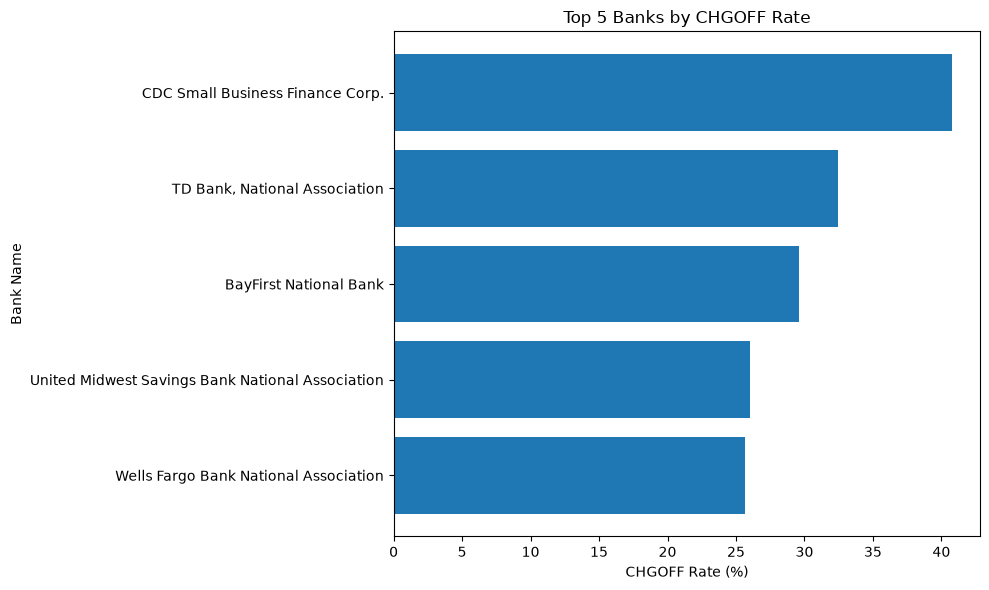

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    bank_chgoff['bank_name'],
    bank_chgoff['chgoff_rate']
)

plt.title('Top 5 Banks by CHGOFF Rate')
plt.xlabel('CHGOFF Rate (%)')
plt.ylabel('Bank Name')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
#which 5 business have the highest charge off rate and charge off amount among states with at least 50 resolved laon?

business_age_risk=(df[(df['loan_status'].isin(['PIF','CHGOFF']))& (df['business_age'].notna())].
           groupby('business_age').agg(total_loans=('loan_status','size'),chgoff_loans=('chargeoff','sum'),
                                       charged_off_amount=('gross_charge_off_Amount','sum')
                                    ))

business_age_risk['chgoff_rate']=(business_age_risk['chgoff_loans'] /business_age_risk['total_loans']*100).round(2)

business_age_risk = (
    business_age_risk
    .reset_index()
)
display=business_age_risk.copy()
display['chgoff_rate']=display['chgoff_rate'].map("{:.2f}%".format)
display["charged_off_amount"] = display["charged_off_amount"].map("${:,.0f}".format)
display

,business_age,total_loans,chgoff_loans,charged_off_amount,chgoff_rate
0,Change of Ownership,7477,338,"$184,667,133",4.52%
1,Existing or more than 2 years old,40732,3487,"$416,463,261",8.56%
2,New Business or 2 years or less,12701,1750,"$116,590,014",13.78%
3,"Startup, Loan Funds will Open Business",11443,1087,"$169,809,351",9.50%
4,Unanswered,2472,166,"$5,995,789",6.72%
5,Unknown,113,65,"$5,281,948",57.52%


Loans analysed: 74,917
Overall CHGOFFF rate: 9.19%

==CHGOFF Rate by Interest Rate Bucket===
interest_bucket total_loans  chgoff_loans chgoff_rate_pct
            <4%       2,352            53           2.25%
           4-6%      34,101          1516           4.45%
           6-8%      15,602          1451           9.30%
          8-10%      10,552          1495          14.17%
         10-12%       8,983          1344          14.96%
         12-15%       3,283          1009          30.73%
           >15%          44            18          40.91%


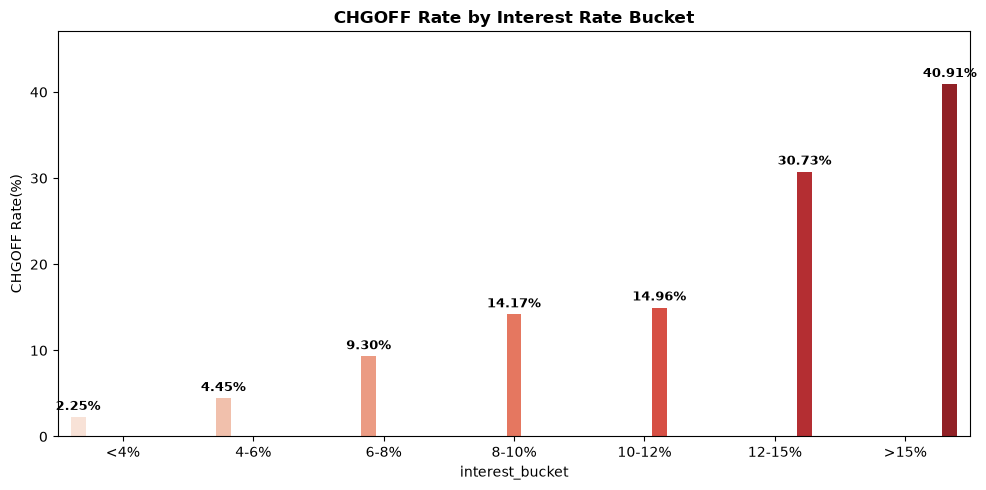

                           Logit Regression Results                           
Dep. Variable:              is_chgoff   No. Observations:                74917
Model:                          Logit   Df Residuals:                    74915
Method:                           MLE   Df Model:                            1
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                 0.07154
Time:                        01:40:37   Log-Likelihood:                -21350.
converged:                       True   LL-Null:                       -22995.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -4.3814      0.042   -105.183      0.000      -4.463      -4.300
initial_interest_rate     0.2628      0.005     57.669      0.000       0.254       0.272

===== L

In [28]:
# Are SBA loans with higher interest rates more likely to be charged off (CHGOFF)?

df_closed=df[df['loan_status'].isin(['PIF','CHGOFF'])].copy()

df_closed['is_chgoff']=np.where(df_closed['loan_status']=="CHGOFF",1,0)

df_clean=df_closed[df_closed['initial_interest_rate']>0].dropna(subset=['initial_interest_rate']).copy()

print(f"Loans analysed: {len(df_clean):,}")
print(f"Overall CHGOFFF rate: {df_clean['is_chgoff'].mean()*100:.2f}%")

df_clean["interest_bucket"]=pd.cut(df_clean["initial_interest_rate"], bins=[0,4,6,8,10,12,15,100],
                                   labels=["<4%", "4-6%", "6-8%", "8-10%", "10-12%", "12-15%", ">15%"])



rate_summary=( df_clean.groupby('interest_bucket', observed=False).agg(total_loans=('is_chgoff','size'), chgoff_loans=('is_chgoff','sum'),
                                                           chgoff_rate=('is_chgoff','mean'),).reset_index())

rate_summary['chgoff_rate_pct']=rate_summary['chgoff_rate']*100
print("\n==CHGOFF Rate by Interest Rate Bucket===")
print( rate_summary.assign(total_loans=rate_summary['total_loans'].map("{:,}".format), 
                           chgoff_rate_pct=rate_summary['chgoff_rate_pct'].map("{:.2f}%".format))
                        [['interest_bucket','total_loans','chgoff_loans','chgoff_rate_pct']].to_string(index=False))


plt.figure(figsize=(10,5))
ax=sns.barplot(data=rate_summary, x='interest_bucket', y='chgoff_rate_pct', hue='interest_bucket', palette='Reds', legend=False,)
plt.title("CHGOFF Rate by Interest Rate Bucket", weight="bold")
plt.xlabel("interest_bucket")
plt.ylabel("CHGOFF Rate(%)")



for p in ax.patches:
    height=p.get_height()
    if not np.isnan(height) and height >0:
        ax.annotate(
            f"{height:.2f}%",
            (p.get_x() +p.get_width()/ 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0,3),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
        )
plt.ylim(0,rate_summary["chgoff_rate_pct"].max()*1.15)
plt.tight_layout()
plt.show()

model=smf.logit("is_chgoff ~ initial_interest_rate",data=df_clean).fit(disp=0)


print(model.summary())
coef =model.params["initial_interest_rate"]
odds_ratio=np.exp(coef)
ci_low,ci_high=np.exp(model.conf_int().loc["initial_interest_rate"])
p_value=model.pvalues["initial_interest_rate"]

print("\n===== Logistic Regression Result =====")
print(f"Coefficient : {coef:.4f}")
print(f"Odds Ratio  : {odds_ratio:.4f}  (95% CI {ci_low:.4f} - {ci_high:.4f})")
print(f"P-value     : {p_value:.2e}")
 
if p_value<0.05:
    pct_change=(odds_ratio-1)*100
    direction="higher" if pct_change>0 else "lower"
    print(
        f"\nEach 1 percentage point increase in interest rate is associated "
        f"with {abs(pct_change):.1f}% {direction} odds of CHGOFF."
    )
else:
    print("n\Interest rate is not statistically significant.")

In [29]:
# Which loan characteristics are associated with CHGOFF after controlling for other factors?
d=df[df["loan_status"].isin(["PIF","CHGOFF"])].copy()
d["is_chgoff"]=(d["loan_status"]=="CHGOFF").astype(int)
d = d[(d["initial_interest_rate"] > 0) & (d["term_in_months"] > 0)]
d=d.dropna(subset=["business_age","business_type","fixed_or_variable_interest_ind"])
d=d[d["business_age"] != "Unanswered"].copy()

d["age_group"]=d["business_age"].map({"Existing or more than 2 years old": "Established",
                                      "New Business or 2 years or less" : "New (=<2 yrs)",
                                      "Startup, Loan Funds will Open Business": "Startup",
                                      "Change of Ownership" : "Change of ownership",})
d["log_amount"]=np.log(d["gross_approval"])
d["guarantee_pct"]=d["sba_guaranteed_approval"] / d["gross_approval"]*100
d["term_band"]=pd.cut(d["term_in_months"],[0,60,119,120,240,600],labels=["<=60","61-119","120","121-240",">=240"])
d["rate_type"]=d["fixed_or_variable_interest_ind"].map({"F":"Fixed","V": "Variable"})
d["collateral"]=d["collateral_ind"].map({"Y": "Yes","N": "No"})

def collapse_rare(s,min_n=500):
    """Merge rare categories into 'Other' (prevents singular-matrix errors)."""
    keep=s.value_counts()
    keep=keep[keep>=min_n].index
    return s.where(s.isin(keep),"Other")
    
d["program"]= collapse_rare(d["processing_method"].astype(str))
d["biz_type"]=d["business_type"].astype(str).str.strip()
print("Business type counts(before filtering):")
print(d.groupby("biz_type")["is_chgoff"].agg(loans="count", chgoff="sum"),"\n")
big_types=d["biz_type"].value_counts()
big_types= big_types[big_types>=500].index
d=d[d["biz_type"].isin(big_types)].copy()
d["approval_fy"]=d["approval_fy"].astype(int)
print(f"Loan analysed: {len(d):,} | CHGOFF rate: {d['is_chgoff'].mean()*100:.2f}%\n")
#Multivariative logistic regression

preferred={
    "term_band":"120",
    "age_group": "Established",
    "collateral":"yes",
    "rate_type": "Fixed",
    "program":"Preferred Lenders Program",
    "biz_type":"CORPORATION",}

for col in preferred:
    d[col]=d[col].astype(str).str.strip()

def ref(col):
    wanted=preferred[col].strip().lower()
    
    for v in d[col].unique():
        if str(v).lower()==wanted:
            return v
    return d[col].value_counts().idxmax()
print("Baseline groups used:")


for col in preferred:
    print(f"{col}:{ref(col)}")
formula=(
    "is_chgoff~ initial_interest_rate +log_amount+ guarantee_pct"
    f"+C(term_band, Treatment('{ref('term_band')}'))"
    f"+C(age_group, Treatment('{ref('age_group')}'))"
    f"+C(collateral, Treatment('{ref('collateral')}'))"
    f"+C(rate_type, Treatment('{ref('rate_type')}'))"
    f"+C(program, Treatment('{ref('program')}'))"
    f"+C(biz_type, Treatment('{ref('biz_type')}'))"
    " + C(approval_fy)")
try:
    model=smf.logit(formula,data=d).fit(disp=0,maxiter=200)
except np.linalg.LinAlgError:
    model=smf.logit(formula,data=d).fit(disp=0,method="bfgs", maxiter=5000)

print(f"Converged: {model.mle_retvals.get('converged', True)}")
print(f"Pseudo R-squared: {model.prsquared:.3f}\n")
    

ci=np.exp(model.conf_int())
res=pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "ci_low" : ci[0],
    "ci_high" :ci[1],
    "p_value": model.pvalues,
}).drop("Intercept")

def clean_name(n):
    if "[T." in n:
        var, level = n.split("[T.")
        var = var.split("(")[1].split(",")[0]
        return f"{var}: {level.rstrip(']')}"
    return n

res.index=[clean_name(n) for n in res.index]
res=res[~res.index.str.startswith("approval_fy")]
res["significant"]=np.where(res["p_value"]<0.05,"Yes","No")
bad=res[(res["odds_ratio"]>1000) | (res["ci_high"]>1000) |(res["ci_low"]<0.001)]


if len(bad):
    print("WARNING: unreliable estimates (tiny group / perfect separation):")
    print(bad.index.tolist(), "\n")
    
print("=== Odds ratios (1.0 = no effect; >1 = higher CHGOFF odds) ===")
print(res.sort_values("odds_ratio", ascending=False).round(3).to_string())


b=model.params
print("\n=== Practical effect sizes ===")
print(f"+1 pt interest rate           : OR = {np.exp(b['initial_interest_rate']):.2f}")
print(f"Loan size doubled (x2)        : OR = {np.exp(b['log_amount'] * np.log(2)):.2f}")
print(f"+10 pts SBA guarantee share   : OR = {np.exp(b['guarantee_pct'] * 10):.2f}")
 

Business type counts(before filtering):
             loans  chgoff
biz_type                  
Corporation  67304    6234
Individual    4316     429
Partnership    815      48
Unknown          2       2 

Loan analysed: 72,435 | CHGOFF rate: 9.26%

Baseline groups used:
term_band:120
age_group:Established
collateral:Yes
rate_type:Fixed
program:Preferred Lenders Program
biz_type:Corporation
Converged: True
Pseudo R-squared: 0.322

=== Odds ratios (1.0 = no effect; >1 = higher CHGOFF odds) ===
                                         odds_ratio  ci_low  ci_high  p_value significant
term_band: 61-119                            17.679  16.358   19.107    0.000         Yes
term_band: <=60                               9.241   8.362   10.214    0.000         Yes
rate_type: Variable                           2.736   2.501    2.993    0.000         Yes
collateral: No                                1.721   1.596    1.855    0.000         Yes
initial_interest_rate                         1.486   